In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../dataset/CEAS_08.csv")
data.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [3]:
y = data["label"]
display(y.head())

0    1
1    1
2    1
3    0
4    1
Name: label, dtype: int64

#### Values Mapping
##### 0 : Normal
##### 1 : Spam

In [4]:
y.value_counts()

label
1    21842
0    17312
Name: count, dtype: int64

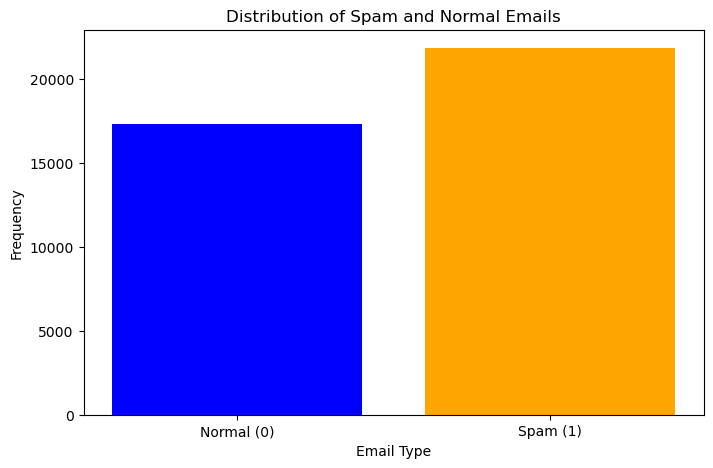

In [5]:
value_counts = [17312, 21842]
labels = ['Normal (0)', 'Spam (1)']

# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(labels, value_counts, color=['blue', 'orange'])
plt.xlabel('Email Type')
plt.ylabel('Frequency')
plt.title('Distribution of Spam and Normal Emails')
plt.show()

In [29]:
normal_data = data[data["label"]==0]
spam_data = data[data["label"]!=0]

In [30]:
print(normal_data.label.value_counts())
print(spam_data.label.value_counts())

label
0    17312
Name: count, dtype: int64
label
1    21842
Name: count, dtype: int64


In [3]:
data["subject_length"] = data["subject"].fillna("").apply(len)
data["body_length"] = data["body"].fillna("").apply(len)

In [36]:
data.groupby("label")["body_length"].mean()

label
0    2542.186287
1     801.379452
Name: body_length, dtype: float64

<Figure size 600x400 with 0 Axes>

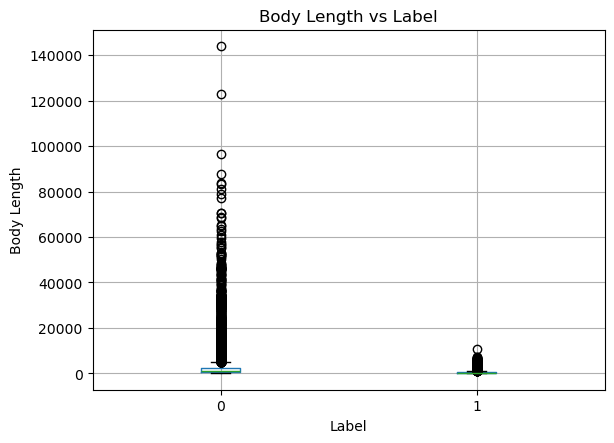

In [37]:
plt.figure(figsize=(6,4))
data.boxplot(column="body_length", by="label")
plt.title("Body Length vs Label")
plt.suptitle("")   # removes extra title added by pandas
plt.xlabel("Label")
plt.ylabel("Body Length")
plt.show()

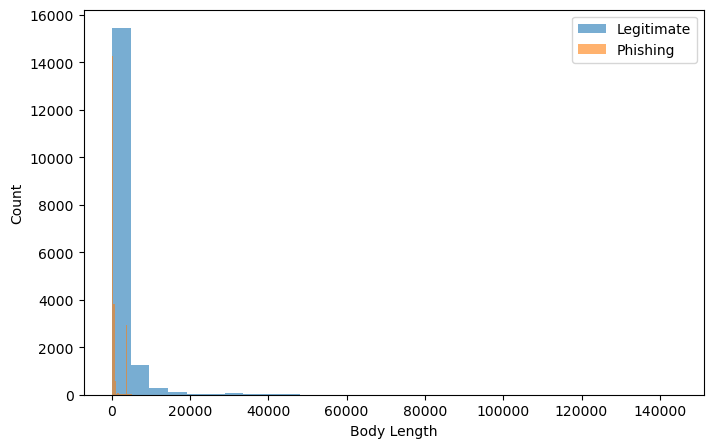

In [38]:
plt.figure(figsize=(8,5))

plt.hist(data[data["label"]==0]["body_length"],
         bins=30,
         alpha=0.6,
         label="Legitimate")

plt.hist(data[data["label"]==1]["body_length"],
         bins=30,
         alpha=0.6,
         label="Phishing")

plt.xlabel("Body Length")
plt.ylabel("Count")
plt.legend()
plt.show()

In [40]:
data.groupby("label")["body_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,2542.186287,5080.634677,14.0,709.00,1252.0,2468.0,143996.0
1,21842.0,801.379452,1279.876356,16.0,160.25,278.0,566.0,10782.0


In [41]:
data[["body_length", "label"]].corr()

,body_length,label
body_length,1.000000,-0.239108
label,-0.239108,1.000000


In [4]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = []
    for word in text.split():
        if word not in stop_words:
            words.append(lemmatizer.lemmatize(word))
    
    return " ".join(words)

In [5]:
data["clean_subject"] = data["subject"].fillna("").apply(clean_text)
data["clean_body"] = data["body"].fillna("").apply(clean_text)

In [6]:
data["clean_text"] = data["clean_subject"] + " " + data["clean_body"]

In [42]:
data["clean_body_length"] = data["clean_body"].fillna("").apply(len)

In [43]:
data.groupby("label")["clean_body_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,1546.385513,3274.892639,0.0,399.0,727.0,1471.25,95599.0
1,21842.0,330.925282,411.912715,3.0,82.0,179.0,409.00,6708.0


In [45]:
data[["clean_body_length", "label"]].corr()

,clean_body_length,label
clean_body_length,1.000000,-0.264697
label,-0.264697,1.000000


In [46]:
data["clean_text_length"] = data["clean_text"].fillna("").apply(len)

In [48]:
data[["clean_text_length", "label"]].corr()

,clean_text_length,label
clean_text_length,1.000000,-0.267157
label,-0.267157,1.000000


In [49]:
data.groupby("label")["clean_text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,1584.301467,3275.683570,14.0,435.0,764.0,1514.0,95637.0
1,21842.0,356.439932,411.074984,11.0,109.0,203.0,434.0,6732.0


In [50]:
data.groupby("label")["subject_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,48.084277,21.247088,0.0,33.0,45.0,61.0,268.0
1,21842.0,31.614321,17.191599,0.0,20.0,27.0,40.0,285.0


In [51]:
data[["subject_length", "label"]].corr()

,subject_length,label
subject_length,1.000000,-0.393834
label,-0.393834,1.000000


In [52]:
data["clean_subject_length"] = data["clean_subject"].fillna("").apply(len)

In [53]:
data.groupby("label")["clean_subject_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,36.915954,17.246403,0.0,25.0,34.0,46.0,221.0
1,21842.0,24.514651,13.381694,0.0,18.0,22.0,31.0,181.0


In [54]:
data[["clean_subject_length", "label"]].corr()

,clean_subject_length,label
clean_subject_length,1.000000,-0.375293
label,-0.375293,1.000000


In [55]:
data["body_uppercase_count"] = data["body"].fillna("").apply(
    lambda x: sum(c.isupper() for c in x)
)
data["body_uppercase_words"] = data["body"].fillna("").apply(
    lambda x: sum(word.isupper() for word in x.split())
)
data["body_uppercase_ratio"] = data["body"].fillna("").apply(
    lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0
)
print("body_uppercase_count")
display(data.groupby("label")["body_uppercase_count"].describe())
display(data[["body_uppercase_count", "label"]].corr())
print("body_uppercase_words")
display(data.groupby("label")["body_uppercase_words"].describe())
display(data[["body_uppercase_words", "label"]].corr())
print("body_uppercase_ratio")
display(data.groupby("label")["body_uppercase_ratio"].describe())
display(data[["body_uppercase_ratio", "label"]].corr())

body_uppercase_count


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,144.718346,481.028296,0.0,24.0,48.0,127.0,26776.0
1,21842.0,99.510484,213.409445,0.0,5.0,10.0,39.0,799.0


,body_uppercase_count,label
body_uppercase_count,1.000000,-0.062704
label,-0.062704,1.000000


body_uppercase_words


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,15.186171,43.621281,0.0,3.0,7.0,15.0,2464.0
1,21842.0,15.401612,35.548750,0.0,0.0,0.0,4.0,192.0


,body_uppercase_words,label
body_uppercase_words,1.000000,0.002721
label,0.002721,1.000000


body_uppercase_ratio


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,0.049495,0.035261,0.0,0.027544,0.040171,0.059466,0.613761
1,21842.0,0.068634,0.071491,0.0,0.019380,0.036560,0.096491,0.713178


,body_uppercase_ratio,label
body_uppercase_ratio,1.000000,0.160877
label,0.160877,1.000000


In [56]:
data["subject_uppercase_count"] = data["subject"].fillna("").apply(
    lambda x: sum(c.isupper() for c in x)
)
data["subject_uppercase_words"] = data["subject"].fillna("").apply(
    lambda x: sum(word.isupper() for word in x.split())
)
data["subject_uppercase_ratio"] = data["subject"].fillna("").apply(
    lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0
)
print("subject_uppercase_count")
display(data.groupby("label")["subject_uppercase_count"].describe())
display(data[["subject_uppercase_count", "label"]].corr())
print("subject_uppercase_words")
display(data.groupby("label")["subject_uppercase_words"].describe())
display(data[["subject_uppercase_words", "label"]].corr())
print("subject_uppercase_ratio")
display(data.groupby("label")["subject_uppercase_ratio"].describe())
display(data[["subject_uppercase_ratio", "label"]].corr())

subject_uppercase_count


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,5.344212,4.793186,0.0,2.0,4.0,7.0,85.0
1,21842.0,2.958658,2.862265,0.0,1.0,2.0,5.0,87.0


,subject_uppercase_count,label
subject_uppercase_count,1.000000,-0.294983
label,-0.294983,1.000000


subject_uppercase_words


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,0.608942,0.974119,0.0,0.0,0.0,1.0,15.0
1,21842.0,0.131993,0.447329,0.0,0.0,0.0,0.0,13.0


,subject_uppercase_words,label
subject_uppercase_words,1.000000,-0.309099
label,-0.309099,1.000000


subject_uppercase_ratio


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,0.118608,0.100266,0.0,0.054545,0.095238,0.156250,1.0
1,21842.0,0.115926,0.104720,0.0,0.030303,0.073171,0.206897,1.0


,subject_uppercase_ratio,label
subject_uppercase_ratio,1.000000,-0.012958
label,-0.012958,1.000000


In [58]:
data["sender_domain"] = (
    data["sender"]
    .str.extract(r"<[^@]+@([^>]+)>")
)
data["sender_domain"].head()

0              iworld.de
1              icable.ph
2    universalnet.psi.br
3              pobox.com
4    loanofficertool.com
Name: sender_domain, dtype: object

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X = data.drop("label", axis=1)
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
train_text = X_train["clean_text"]
test_text = X_test["clean_text"]

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)

In [11]:
X_train_text = vectorizer.fit_transform(train_text)
X_test_text = vectorizer.transform(test_text)

In [12]:
X_train_num = X_train[["urls", "subject_length", "body_length"]]
X_test_num = X_test[["urls", "subject_length", "body_length"]]

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [14]:
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

In [15]:
from scipy.sparse import hstack

In [16]:
X_train_final = hstack([
    X_train_text,
    X_train_num
])
X_test_final = hstack([
    X_test_text,
    X_test_num
])
X_train_final_scaled = hstack([
    X_train_text,
    X_train_num_scaled
])
X_test_final_scaled = hstack([
    X_test_text,
    X_test_num_scaled
])

In [17]:
from sklearn.model_selection import cross_val_score
#GridSearchCV
#RandomizedSearchCV

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [20]:
lr = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
svc = LinearSVC(C=1.0, random_state=42)
mnb = MultinomialNB(alpha=1.0)
rfc = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2,
                             random_state=42, n_jobs=-1)
xgbc = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, subsample=0.8, 
                     colsample_bytree=0.8, eval_metric="logloss", random_state=42)

models = {"Logistic Regression": lr,
          "SVM": svc,
          "Naive Bayes": mnb,
          "Random Forest": rfc,
          "XGBoost": xgbc
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_final, y_train, cv=5, scoring="f1")
    print(name, scores, "\n\tmean:", scores.mean(), "\n\tstd:", scores.std())

Logistic Regression [0.98898899 0.99186992 0.9828816  0.98129907 0.97158284] 
	mean: 0.9833244827060099 
	std: 0.007032436414344275
SVM [0.98053807 0.99157504 0.95348189 0.98956994 0.97535964] 
	mean: 0.9781049145232504 
	std: 0.013657532348317474
Naive Bayes [0.76522415 0.76799793 0.76591322 0.76054159 0.76599064] 
	mean: 0.7651335066525405 
	std: 0.002475541158167165
Random Forest [0.99283051 0.9951373  0.9957057  0.99341352 0.99269446] 
	mean: 0.9939562966411831 
	std: 0.001233645771168955
XGBoost [0.99170955 0.99358151 0.99286326 0.99299099 0.99043813] 
	mean: 0.9923166889695183 
	std: 0.001118105109966904
